In [26]:
import sys, os
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.getcwd()  # fallback for Jupyter

sys.path.insert(0, _HERE)
import matplotlib.patches as mpatches
from scipy import stats
from scipy.optimize import minimize

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_pipeline import get_split, get_industry_names, get_excess
from portfolio_core import ewp, gmv, tan


In [27]:
excess      = get_excess()
industries  = get_industry_names()
mkt_returns = excess['Mkt-RF'].values          # (360,)
ind_returns = excess[industries].values        # (360, 43)
 
CONF_LEVELS = [0.95, 0.99]
COLORS      = {'hist': '#5B8DB8', 'normal': '#C0392B', 'var95': '#E67E22', 'var99': '#8E44AD'}

In [28]:
#helper
def plot_one(ax, returns, title, show_legend=False, fontsize=9):
    mu    = returns.mean()
    sigma = returns.std(ddof=1)
    skew  = stats.skew(returns)
    kurt  = stats.kurtosis(returns)          # excess kurtosis (normal = 0)
 
    # Histogram (density)
    ax.hist(returns, bins=100, density=True,
            color=COLORS['hist'], alpha=0.55, edgecolor='white', linewidth=0.4)
 
    # Fitted normal PDF
    x = np.linspace(returns.min() - 1, returns.max() + 1, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color=COLORS['normal'], linewidth=1.5, label='Normal fit')
 
    for conf, color_key, ls in [(0.95, 'var95', '--'), (0.99, 'var99', ':')]:
        var_val = stats.norm.ppf(1 - conf, loc=mu, scale=sigma)
        ax.axvline(var_val, color=COLORS[color_key], linewidth=1.3,
                linestyle=ls, label=f'VaR {int(conf*100)}% = {var_val:.2f}%')

    # Annotations: skew + excess kurtosis
    ax.annotate(
        f'skew={skew:.2f}  kurt={kurt:.2f}',
        xy=(0.97, 0.97), xycoords='axes fraction',
        ha='right', va='top', fontsize=fontsize - 1,
        color='#444444',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none')
    )
 
    ax.set_title(title, fontsize=fontsize, pad=3)
    ax.tick_params(labelsize=fontsize - 1)
    ax.set_xlabel('Monthly return (%)', fontsize=fontsize - 1)
    ax.set_ylabel('Density', fontsize=fontsize - 1)
    ax.grid(True, alpha=0.25, linewidth=0.5)
 
    if show_legend:
        ax.legend(fontsize=fontsize - 1, loc='upper left')

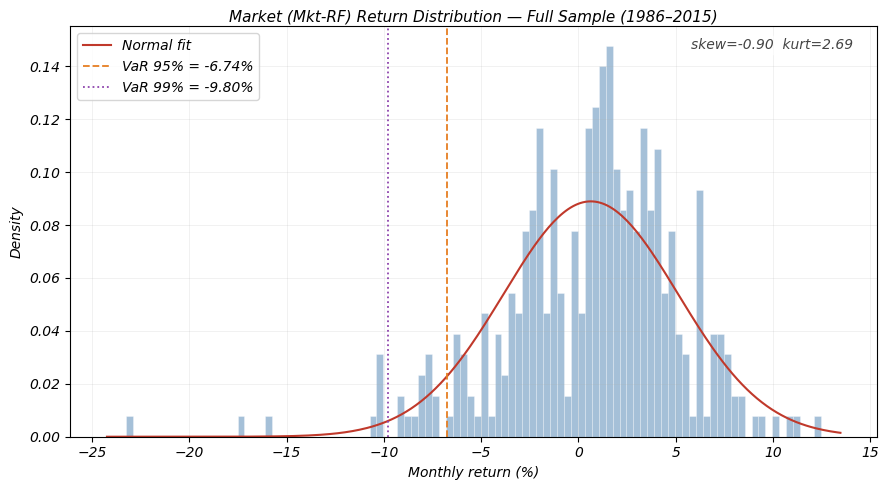

✅ Saved: VaR_market_distribution.png


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1: Market return distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
plot_one(ax, mkt_returns, title='Market (Mkt-RF) Return Distribution — Full Sample (1986–2015)',
         show_legend=True, fontsize=11)
  
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
 
out_dir = os.path.join(_HERE, '..', 'outputs', 'figures')
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, 'VaR_market_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: VaR_market_distribution.png")

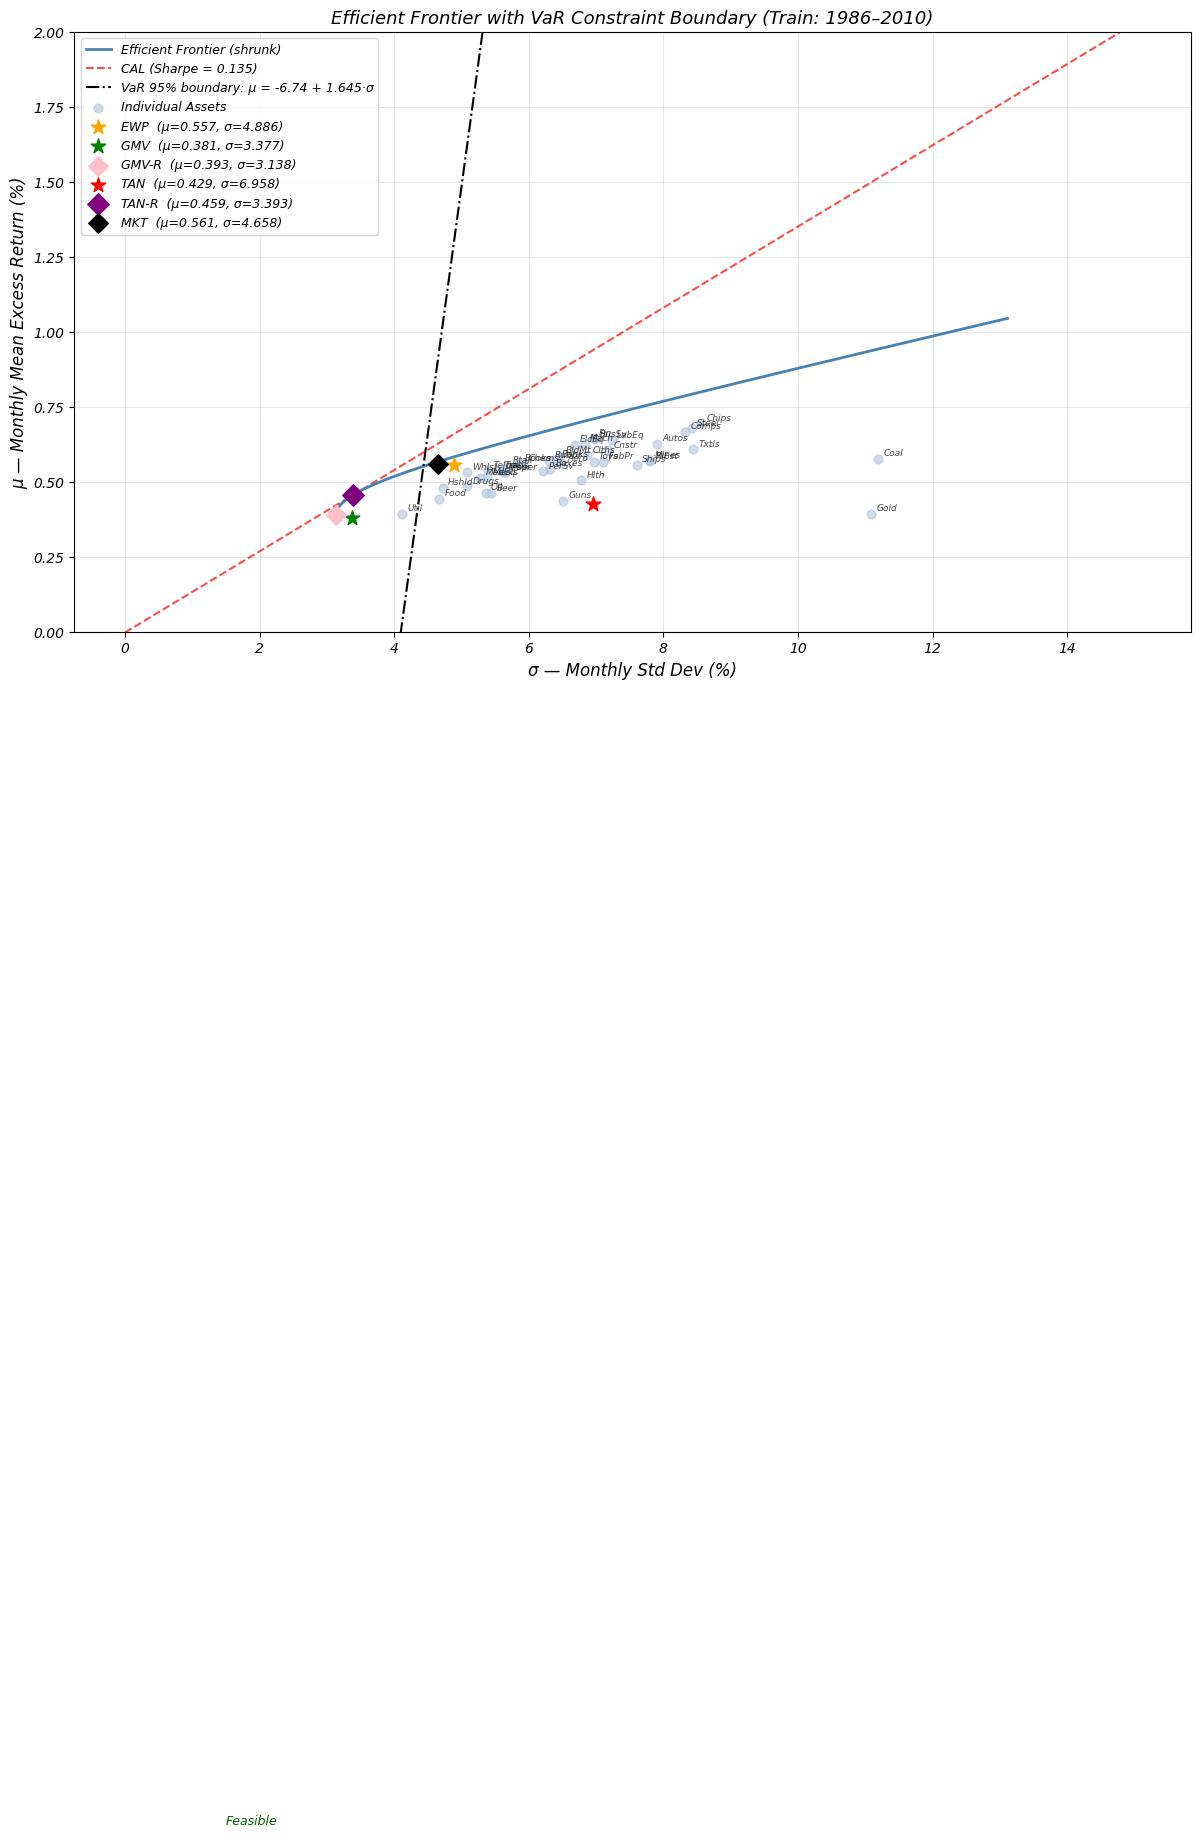

✅ Saved: VaR_constrained_EF.png


In [30]:
# ── Replicate robust_portfolios shrinkage exactly ──────────────────────────────
train, test   = get_split()
industries    = get_industry_names()
r_train       = train[industries].values    # (300, 43)
mkt_train     = train['Mkt-RF'].values      # (300,)
n             = r_train.shape[1]
# Beta shrinkage
def compute_beta_vector(r, mkt):
    betas = []
    for i in range(r.shape[1]):
        cov = np.cov(r[:, i], mkt)[0, 1]
        var = np.var(mkt, ddof=1)
        betas.append(cov / var)
    return np.array(betas)
 
beta_hat    = compute_beta_vector(r_train, mkt_train)
beta_bar    = np.mean(beta_hat)
beta_shrink = 0.5 * beta_bar + 0.5 * beta_hat
 
mu_mkt_train = np.mean(mkt_train)
mu_capm      = beta_shrink * mu_mkt_train       # (43,) shrunk expected returns
 
# Covariance shrinkage
Sigma_hat = np.cov(r_train, rowvar=False)
corr      = np.corrcoef(r_train, rowvar=False)
avg_corr  = np.mean(corr[np.triu_indices(n, k=1)])
std       = np.sqrt(np.diag(Sigma_hat))
Sigma_cc  = avg_corr * np.outer(std, std)
np.fill_diagonal(Sigma_cc, std**2)
Sigma_shrink = 0.3 * Sigma_cc + 0.7 * Sigma_hat
 
# ── Portfolio weights (shrunk) ─────────────────────────────────────────────────
mu_train_vec = r_train.mean(axis=0)
 
w_ewp,   _, _ = ewp(n)
w_gmv,   _, _ = gmv(Sigma_hat)
w_tan,   _, _ = tan(mu_train_vec, Sigma_hat)
w_tan_r, _, _ = tan(mu_capm, Sigma_shrink)
w_gmv_r, _, _ = gmv(Sigma_shrink)
 
# ── Evaluate all portfolios on TRAIN ──────────────────────────────────────────
def port_stats(w, mu_vec, Sigma):
    mu    = w @ mu_vec
    sigma = np.sqrt(w @ Sigma @ w)
    return mu, sigma
 
# Evaluate using shrunk parameters for consistency
mu_ewp,   sigma_ewp   = port_stats(w_ewp,   mu_capm, Sigma_shrink)
mu_gmv,   sigma_gmv   = port_stats(w_gmv,   mu_capm, Sigma_shrink)
mu_tan,   sigma_tan   = port_stats(w_tan,   mu_capm, Sigma_shrink)
mu_tan_r, sigma_tan_r = port_stats(w_tan_r, mu_capm, Sigma_shrink)
mu_gmv_r, sigma_gmv_r = port_stats(w_gmv_r, mu_capm, Sigma_shrink)
 
mu_mkt    = mkt_train.mean()
sigma_mkt = mkt_train.std(ddof=1)
 
# ── Trace EF using shrunk parameters ──────────────────────────────────────────
# Find GMV on shrunk frontier first
w_gmv_shrunk, _, _ = gmv(Sigma_shrink)
mu_gmv_shrunk       = w_gmv_shrunk @ mu_capm
sigma_gmv_shrunk    = np.sqrt(w_gmv_shrunk @ Sigma_shrink @ w_gmv_shrunk)
 
target_mus = np.linspace(mu_gmv_shrunk, mu_capm.max() * 1.5, 200)
ef_sigmas  = []
 
for target in target_mus:
    res = minimize(
        fun         = lambda w: w @ Sigma_shrink @ w,
        x0          = np.ones(n) / n,
        method      = 'SLSQP',
        constraints = [
            {'type': 'eq', 'fun': lambda w: w.sum() - 1},
            {'type': 'eq', 'fun': lambda w: w @ mu_capm - target}
        ]
    )
    ef_sigmas.append(np.sqrt(res.fun) if res.success else np.nan)
 
ef_sigmas  = np.array(ef_sigmas)
valid      = ~np.isnan(ef_sigmas)
 
# ── VaR constraint boundary: mu = -6.74 + 1.645 * sigma ──────────────────────
VAR_95     = -6.74
Z_95       = 1.645
sigma_range = np.linspace(0, ef_sigmas[valid].max() * 1.15, 300)
var_line    = VAR_95 + Z_95 * sigma_range
 
# ── CAL through origin and robust TAN ─────────────────────────────────────────
sharpe_tan_r = mu_tan_r / sigma_tan_r
cal_x        = np.linspace(0, ef_sigmas[valid].max() * 1.15, 300)
cal_y        = sharpe_tan_r * cal_x
 
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
 
# EF curve
ax.plot(ef_sigmas[valid], target_mus[valid],
        color='steelblue', linewidth=2, zorder=3, label='Efficient Frontier (shrunk)')
 
# CAL
ax.plot(cal_x, cal_y,
        color='red', linewidth=1.5, linestyle='--', alpha=0.7,
        label=f'CAL (Sharpe = {sharpe_tan_r:.3f})')
 
# VaR constraint boundary
ax.plot(sigma_range, var_line,
        color='black', linewidth=1.5, linestyle='-.', zorder=4,
        label=f'VaR 95% boundary: μ = {VAR_95} + 1.645·σ')
 
# Annotate feasible / infeasible
ax.text(1.5, VAR_95 + Z_95 * 1.5 + 0.3, 'Feasible',
        fontsize=9, color='darkgreen', style='italic')
 
# Individual asset points (shrunk parameters)
asset_mus    = mu_capm
asset_sigmas = np.sqrt(np.diag(Sigma_shrink))

ax.scatter(asset_sigmas, asset_mus,
           color='lightsteelblue', alpha=0.6, s=40, zorder=2, label='Individual Assets')

for i, name in enumerate(industries):
    ax.annotate(name, (asset_sigmas[i], asset_mus[i]),
                fontsize=6.5, alpha=0.7,
                xytext=(4, 2), textcoords='offset points')

# Portfolio points
points = [
    (sigma_ewp,   mu_ewp,   'orange', '*', 120, f'EWP  (μ={mu_ewp:.3f}, σ={sigma_ewp:.3f})'),
    (sigma_gmv,   mu_gmv,   'green',  '*', 120, f'GMV  (μ={mu_gmv:.3f}, σ={sigma_gmv:.3f})'),
    (sigma_gmv_r, mu_gmv_r, 'pink',   'D', 100, f'GMV-R  (μ={mu_gmv_r:.3f}, σ={sigma_gmv_r:.3f})'),
    (sigma_tan,   mu_tan,   'red',    '*', 120, f'TAN  (μ={mu_tan:.3f}, σ={sigma_tan:.3f})'),
    (sigma_tan_r, mu_tan_r, 'purple', 'D', 120, f'TAN-R  (μ={mu_tan_r:.3f}, σ={sigma_tan_r:.3f})'),
    (sigma_mkt,   mu_mkt,   'black',  'D', 100, f'MKT  (μ={mu_mkt:.3f}, σ={sigma_mkt:.3f})'),
]
 
for sx, my, color, marker, size, label in points:
    ax.scatter(sx, my, color=color, s=size, marker=marker, zorder=5, label=label)
 
ax.set_xlabel('σ — Monthly Std Dev (%)', fontsize=12)
ax.set_ylabel('μ — Monthly Mean Excess Return (%)', fontsize=12)
ax.set_title('Efficient Frontier with VaR Constraint Boundary (Train: 1986–2010)', fontsize=13)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(0, 2)
 
out_dir = os.path.join(_HERE, '..', 'outputs', 'figures')
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, 'VaR_constrained_EF.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: VaR_constrained_EF.png")

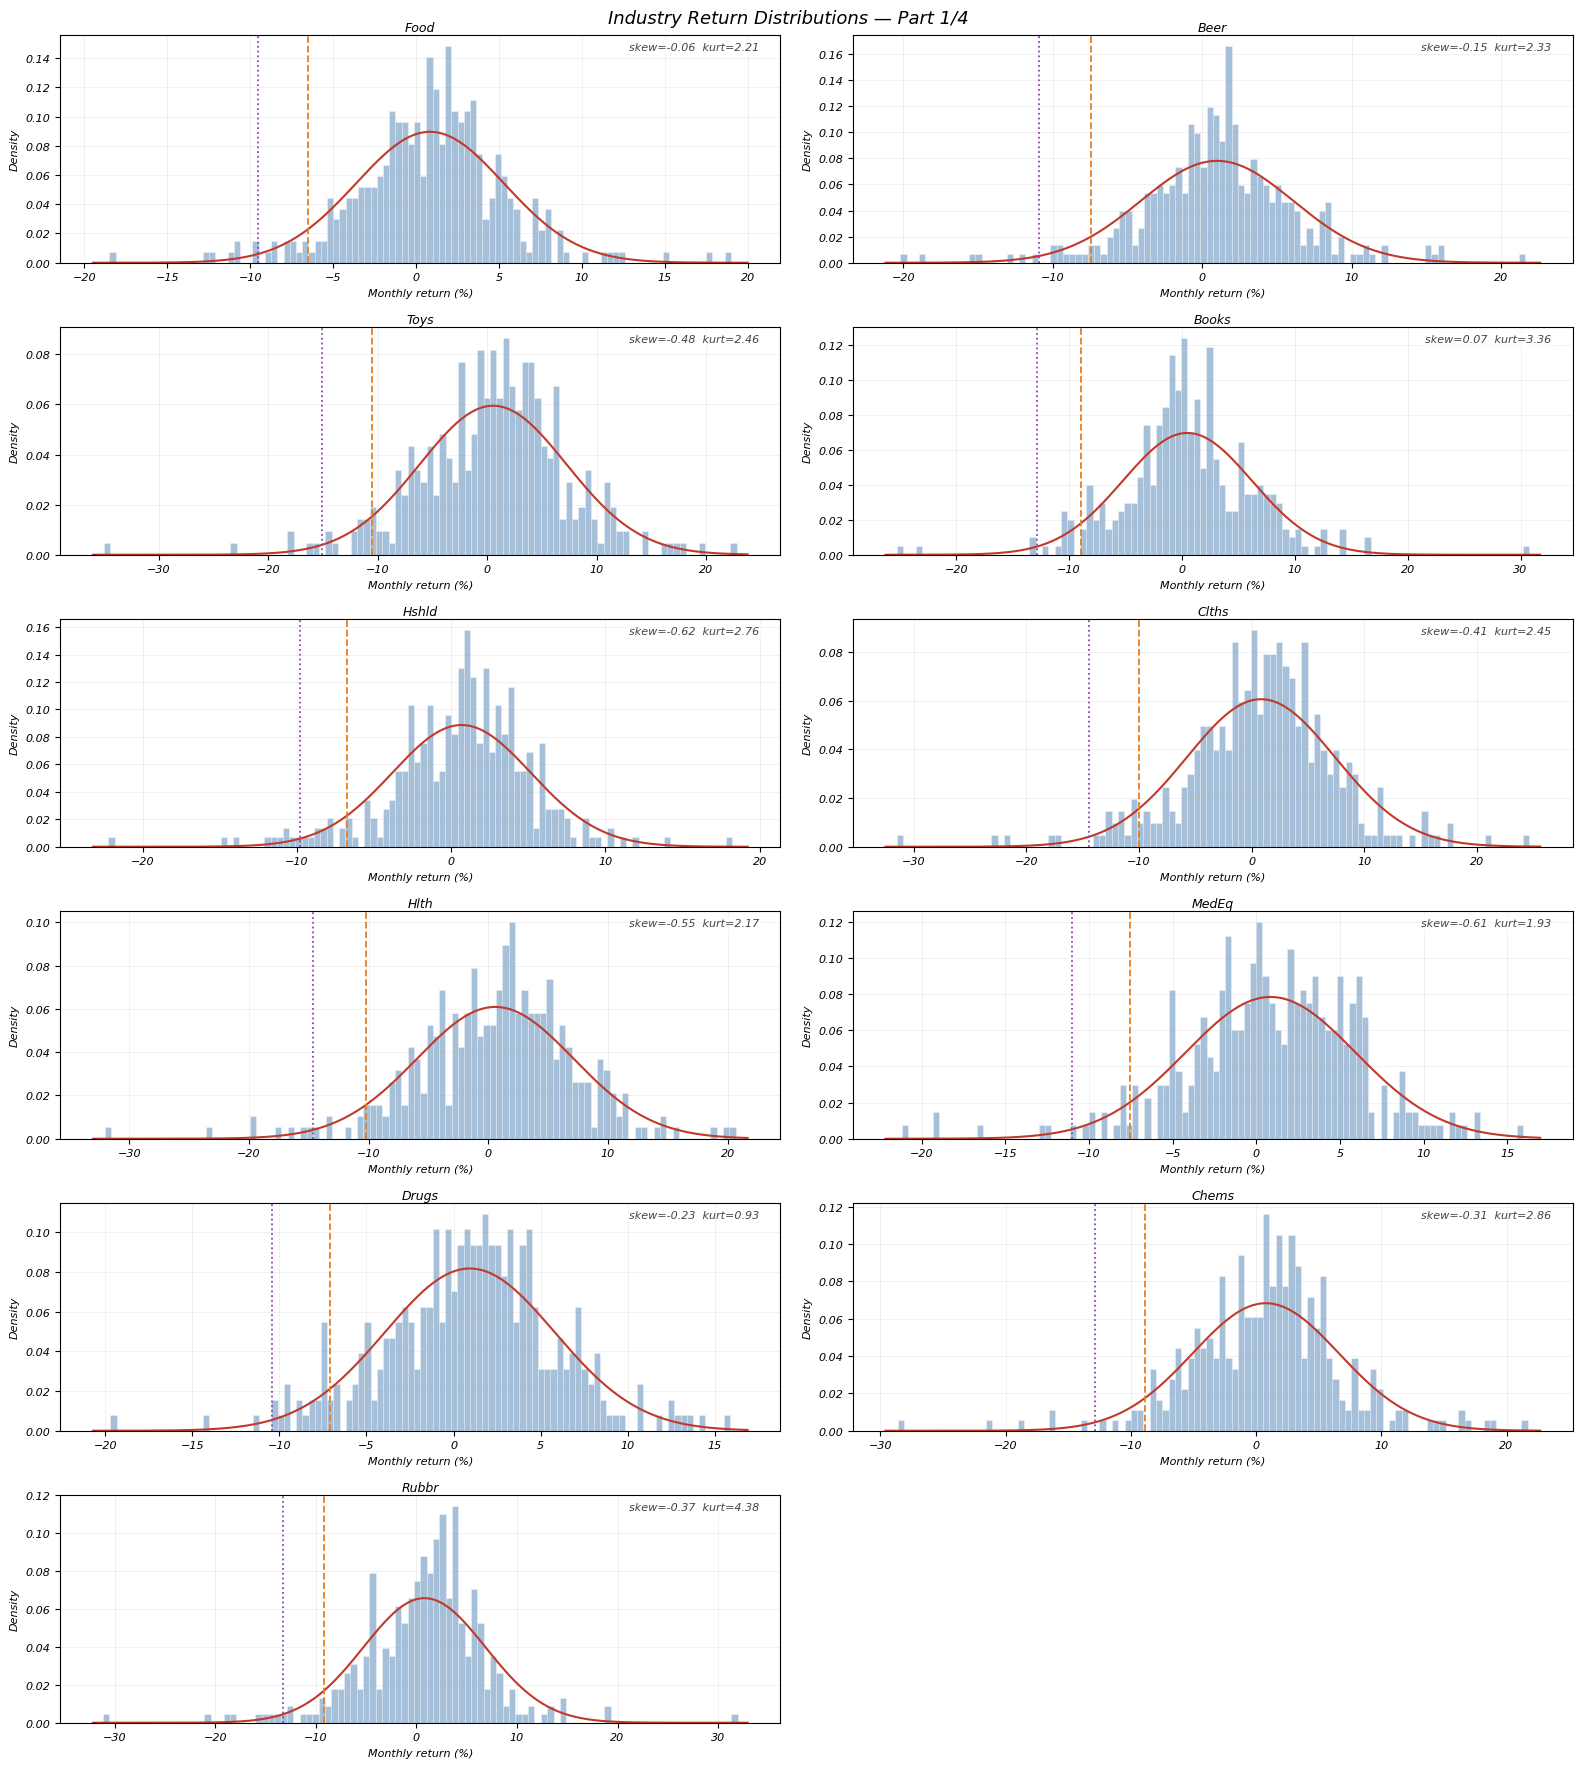

✅ Saved part 1


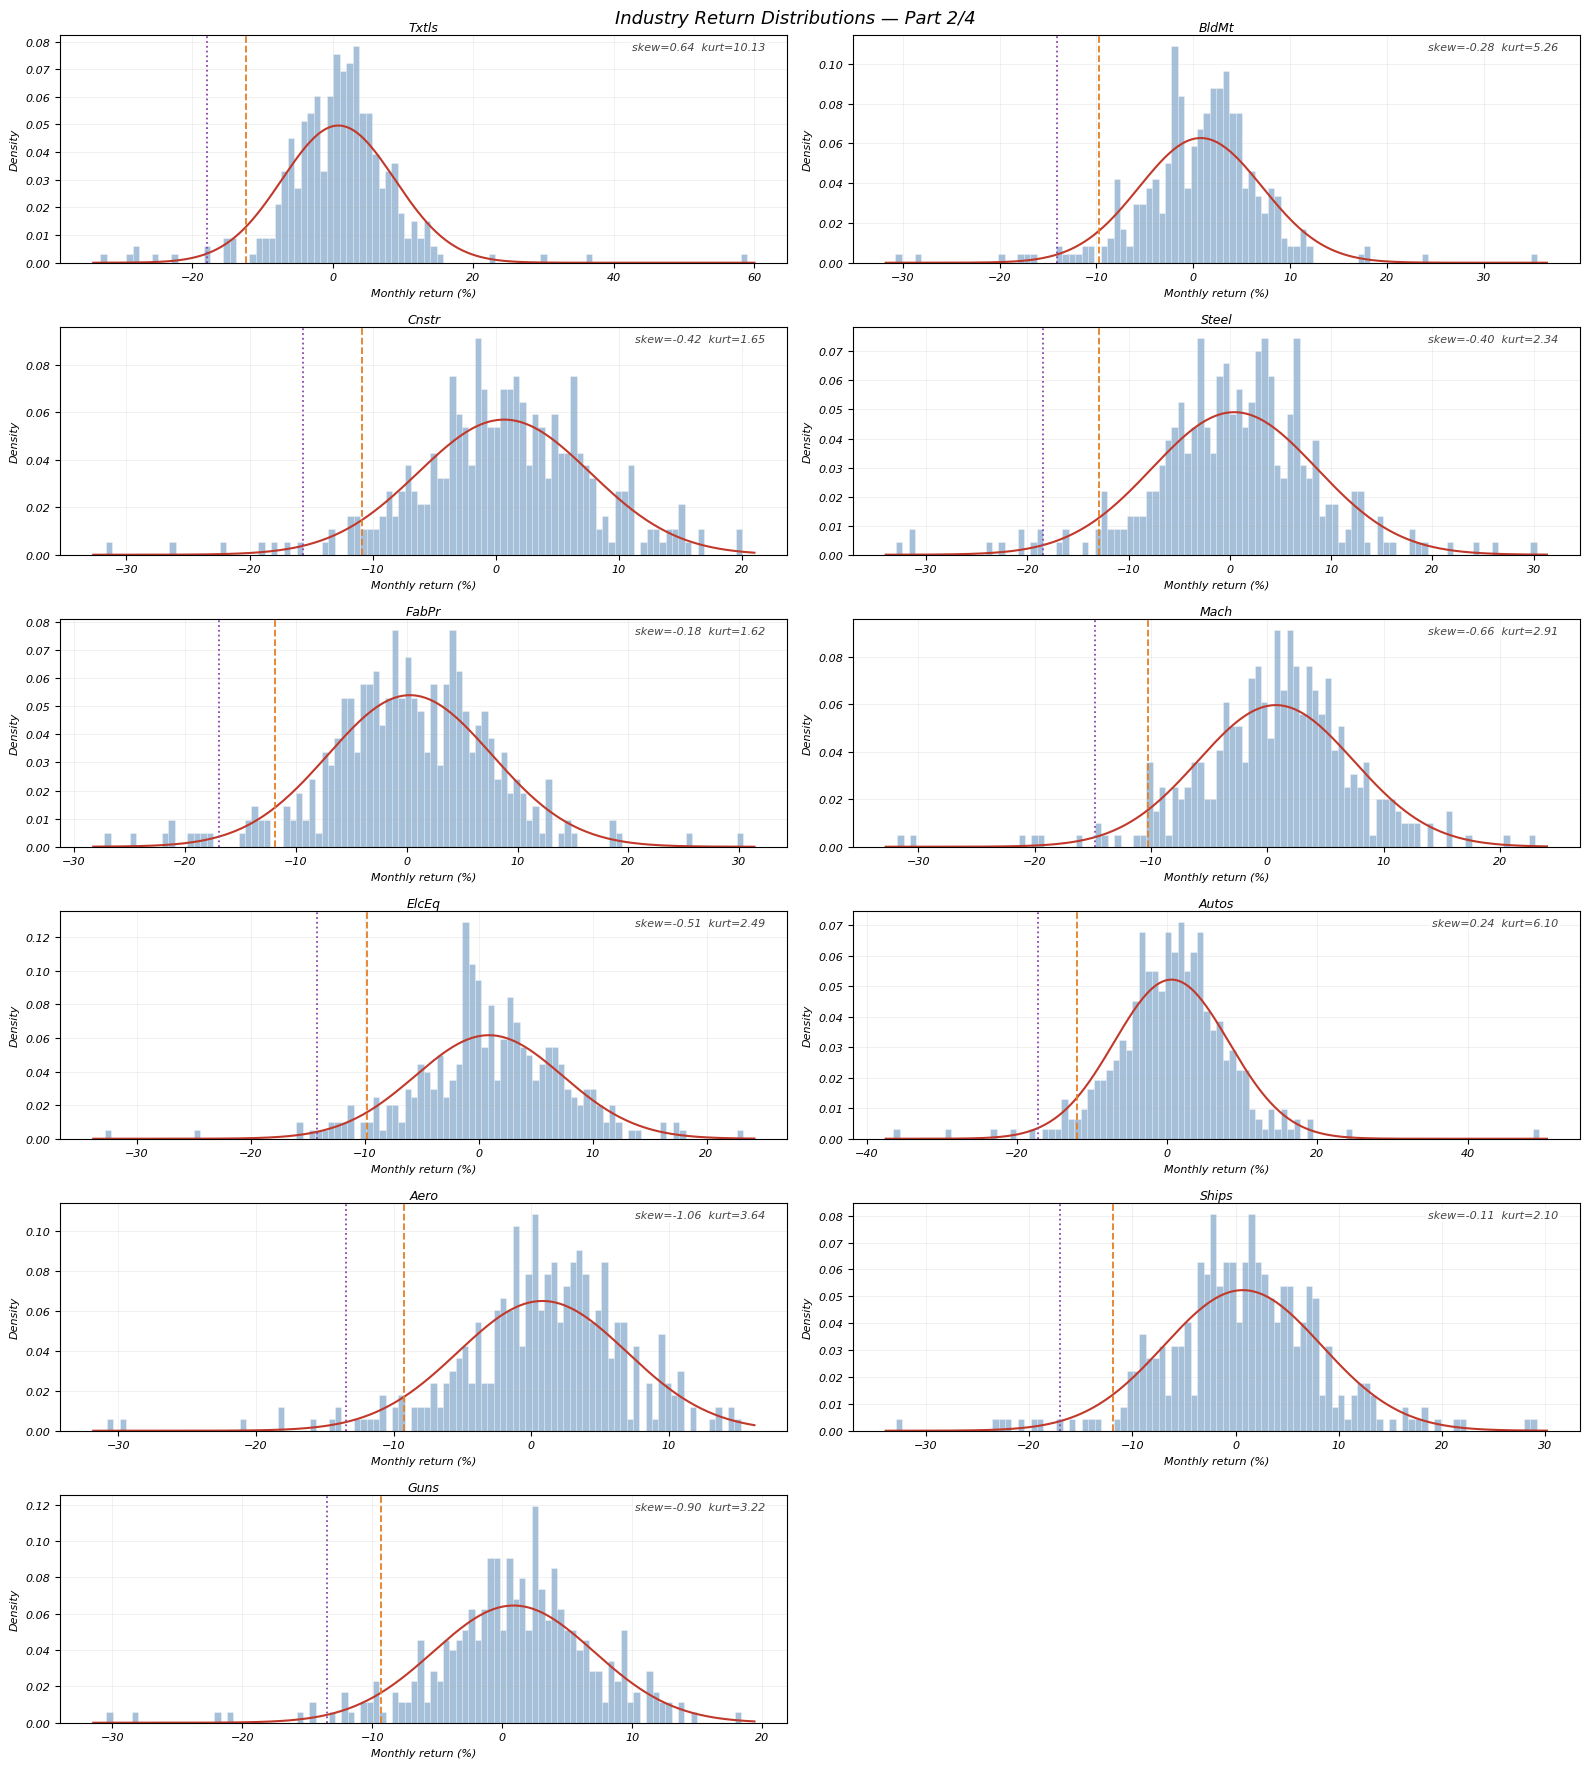

✅ Saved part 2


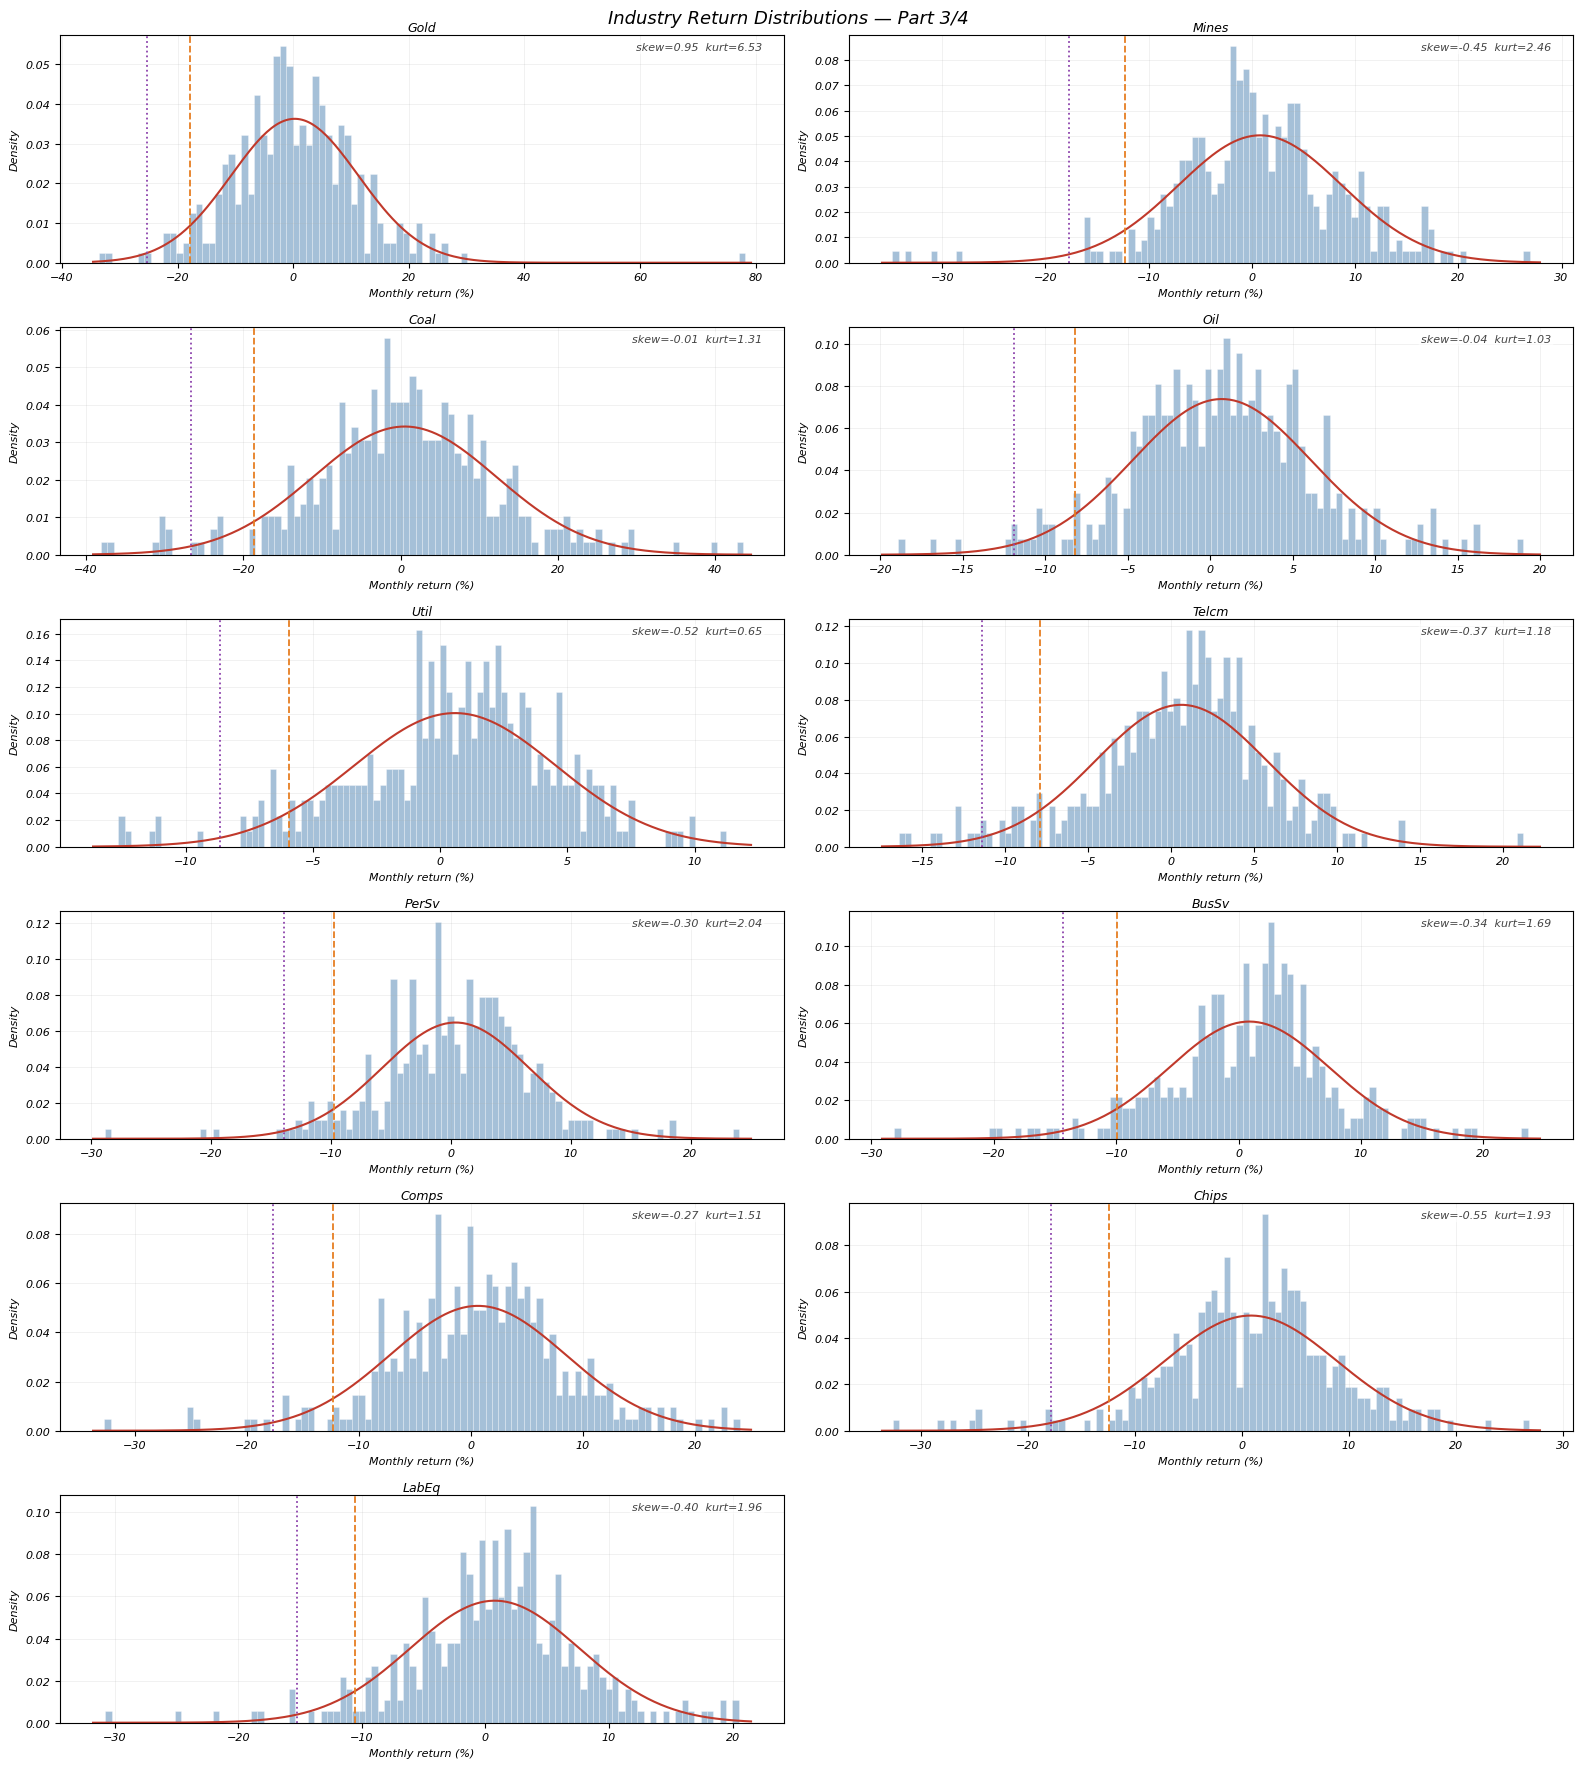

✅ Saved part 3


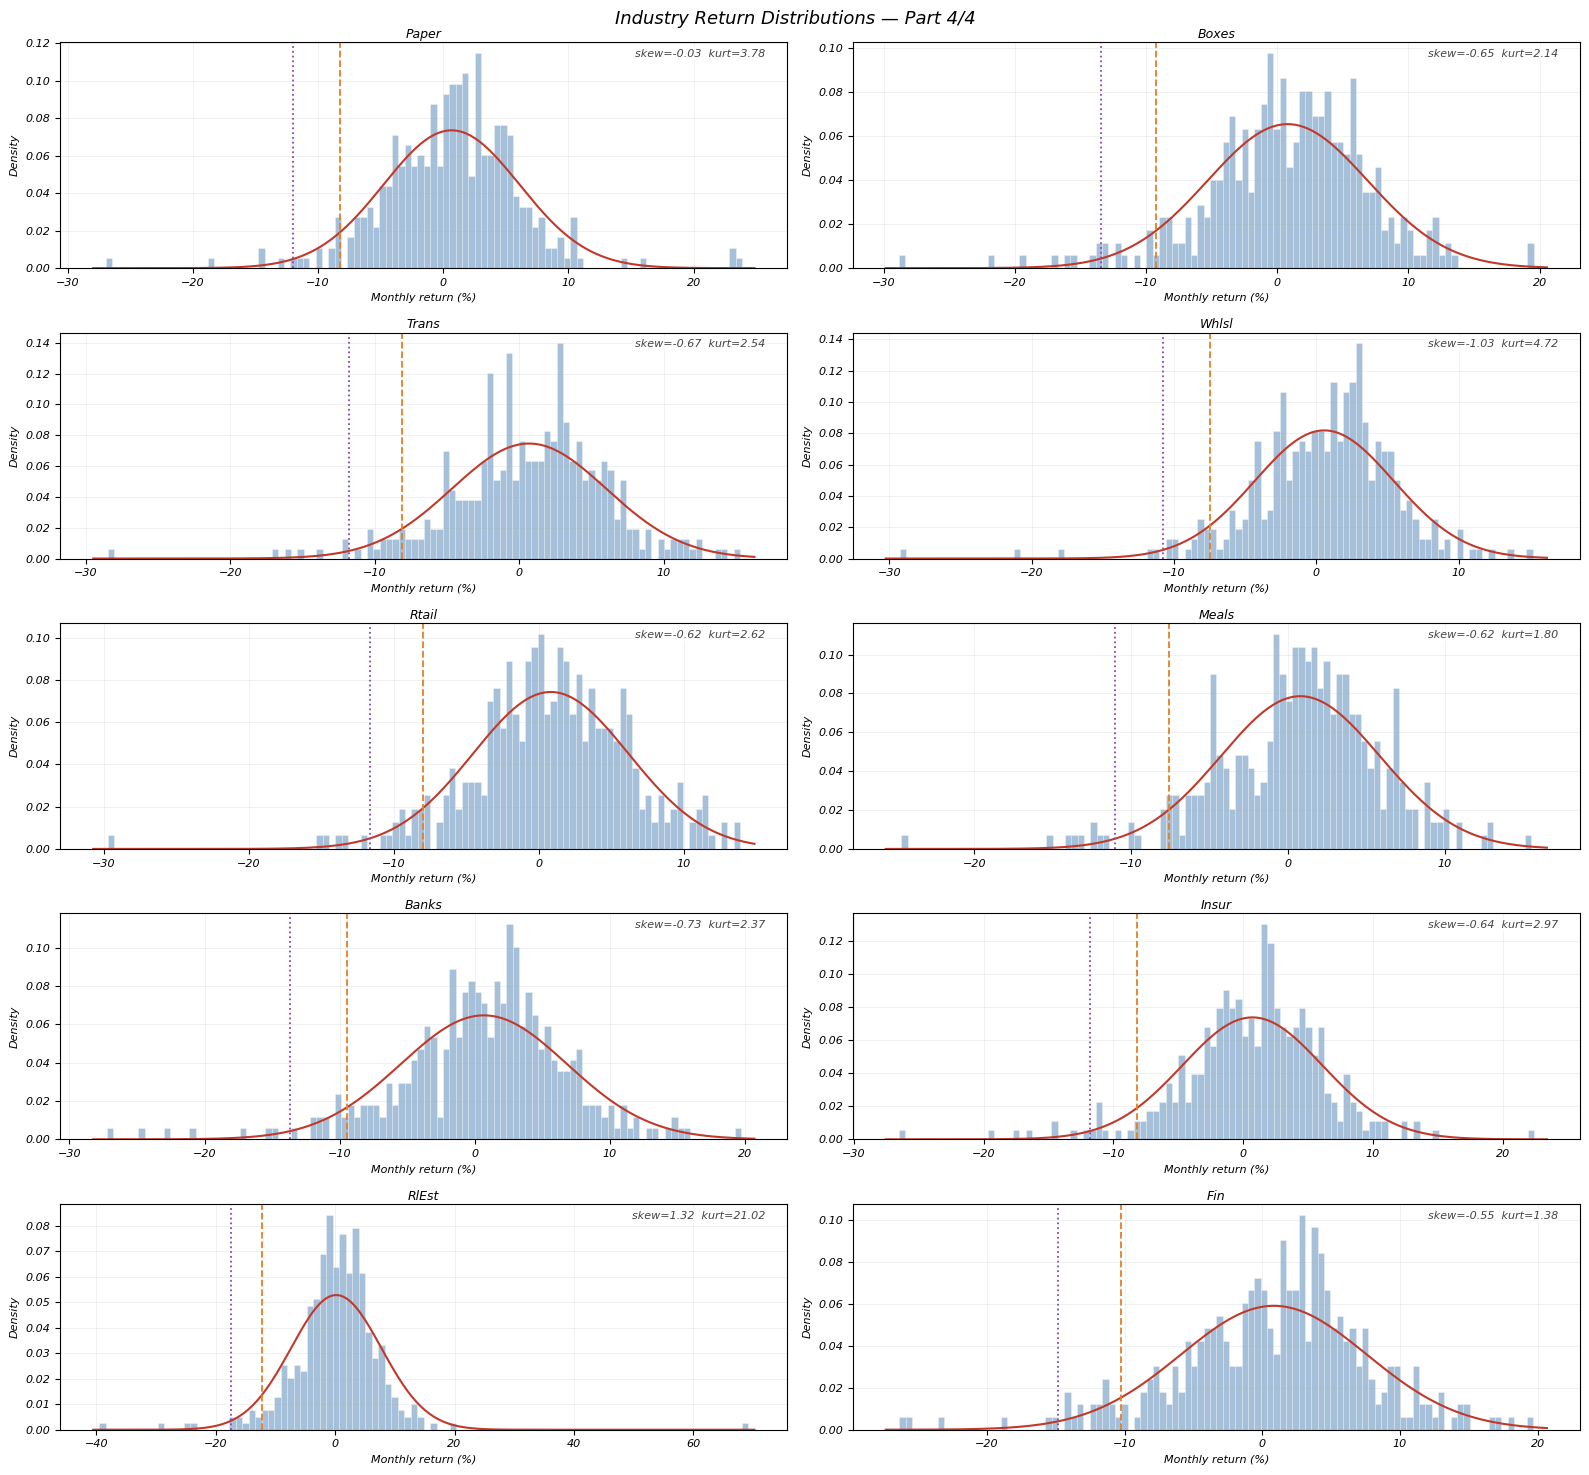

✅ Saved part 4


In [31]:
slices = [
    (industries[0:11],  ind_returns[:, 0:11]),
    (industries[11:22], ind_returns[:, 11:22]),
    (industries[22:33], ind_returns[:, 22:33]),
    (industries[33:43], ind_returns[:, 33:43]),
]

for fig_idx, (names, data) in enumerate(slices):
    nrows = (len(names) + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(16, nrows * 3))
    axes_flat = axes.flatten()

    for i, name in enumerate(names):
        plot_one(axes_flat[i], data[:, i], title=name, show_legend=False, fontsize=9)

    for j in range(len(names), len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(f'Industry Return Distributions — Part {fig_idx + 1}/4', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'VaR_industry_part{fig_idx + 1}.png'), dpi=130, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved part {fig_idx + 1}")

# Hyperparameter search

In [32]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from data_pipeline import get_split, get_industry_names
from portfolio_core import get_sharpe

train, test = get_split()
industries  = get_industry_names()
r_train     = train[industries].values
r_test      = test[industries].values
mkt_train   = train['Mkt-RF'].values
mkt_test    = test['Mkt-RF'].values
T, N        = r_train.shape

# ── Fixed inputs ───────────────────────────────────────────────────────────────
mu_mkt_train = mkt_train.mean()
Sigma_hat    = np.cov(r_train, rowvar=False)

# Covariance shrinkage (fixed — only tuning beta shrinkage)
corr     = np.corrcoef(r_train, rowvar=False)
avg_corr = np.mean(corr[np.triu_indices(N, k=1)])
std      = np.sqrt(np.diag(Sigma_hat))
Sigma_cc = avg_corr * np.outer(std, std)
np.fill_diagonal(Sigma_cc, std**2)
Sigma_shrink = 0.3 * Sigma_cc + 0.7 * Sigma_hat

# ── Beta estimates ─────────────────────────────────────────────────────────────
beta_hat  = np.array([np.cov(r_train[:, i], mkt_train)[0,1] / np.var(mkt_train, ddof=1)
                      for i in range(N)])
beta_bar  = beta_hat.mean()

# ── Helper: build TAN given shrinkage coefficient ──────────────────────────────
def tan_with_coef(coef):
    beta_shrunk = (1 - coef) * beta_hat + coef * beta_bar
    mu_capm     = beta_shrunk * mu_mkt_train

    result = minimize(
        fun         = lambda w: -(w @ mu_capm) / np.sqrt(w @ Sigma_shrink @ w),
        x0          = np.ones(N) / N,
        method      = 'SLSQP',
        constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}
    )
    return result.x, mu_capm

def oos_sharpe(w):
    r      = r_test @ w
    mu     = r.mean()
    sigma  = r.std(ddof=1)
    return get_sharpe(mu, sigma)

# ── Grid search ────────────────────────────────────────────────────────────────
coefs   = np.linspace(0, 1, 101)   # 0.00, 0.01, ..., 1.00
results = []

for coef in coefs:
    w, _ = tan_with_coef(coef)
    sharpe = oos_sharpe(w)
    results.append({'coef': round(coef, 2), 'oos_sharpe': round(sharpe, 4)})

df_results = pd.DataFrame(results)
best       = df_results.loc[df_results['oos_sharpe'].idxmax()]

print("=" * 45)
print("BETA SHRINKAGE HYPERPARAMETER SEARCH")
print("=" * 45)
print(f"Best coefficient : {best['coef']}")
print(f"Best OOS Sharpe  : {best['oos_sharpe']}")
print("=" * 45)
print("\nFull results:")
print(df_results.to_string(index=False))

BETA SHRINKAGE HYPERPARAMETER SEARCH
Best coefficient : 0.59
Best OOS Sharpe  : 0.4273

Full results:
 coef  oos_sharpe
 0.00      0.2720
 0.01      0.2764
 0.02      0.2822
 0.03      0.2866
 0.04      0.2910
 0.05      0.2966
 0.06      0.3009
 0.07      0.3051
 0.08      0.3104
 0.09      0.3143
 0.10      0.3190
 0.11      0.3233
 0.12      0.3274
 0.13      0.3318
 0.14      0.3360
 0.15      0.3403
 0.16      0.3446
 0.17      0.3480
 0.18      0.3519
 0.19      0.3557
 0.20      0.3594
 0.21      0.3633
 0.22      0.3667
 0.23      0.3701
 0.24      0.3734
 0.25      0.3766
 0.26      0.3798
 0.27      0.3829
 0.28      0.3858
 0.29      0.3886
 0.30      0.3913
 0.31      0.3941
 0.32      0.3967
 0.33      0.3991
 0.34      0.4013
 0.35      0.4039
 0.36      0.4059
 0.37      0.4079
 0.38      0.4094
 0.39      0.4112
 0.40      0.4128
 0.41      0.4144
 0.42      0.4160
 0.43      0.4175
 0.44      0.4188
 0.45      0.4199
 0.46      0.4209
 0.47      0.4218
 0.48      0.422

In [33]:
VAR_95 = -6.74
Z_95   = 1.645

def tan_var_constrained(mu_vec, cov):
    n = cov.shape[0]
    result = minimize(
        fun     = lambda w: -(w @ mu_vec) / np.sqrt(w @ cov @ w),
        x0      = np.ones(n) / n,
        method  = 'SLSQP',
        constraints = [
            {'type': 'eq',  'fun': lambda w: w.sum() - 1},
            {'type': 'ineq','fun': lambda w: (w @ mu_vec) - Z_95 * np.sqrt(w @ cov @ w) - VAR_95}
        ]
    )
    mu    = result.x @ mu_vec
    sigma = np.sqrt(result.x @ cov @ result.x)
    return result.x, mu, sigma

In [34]:
# ── Best coefficient from grid search ─────────────────────────────────────────
best_coef    = best['coef']
beta_shrunk  = (1 - best_coef) * beta_hat + best_coef * beta_bar
mu_capm_best = beta_shrunk * mu_mkt_train

w_tan_rs, mu_tan_rs, sigma_tan_rs = tan_var_constrained(mu_capm_best, Sigma_shrink)
sharpe_tan_rs = get_sharpe(mu_tan_rs, sigma_tan_rs)

print("=" * 80)
print("IN-SAMPLE PERFORMANCE (TAN variants)")
print(f"TAN-R-search uses best beta coef = {best_coef}")

IN-SAMPLE PERFORMANCE (TAN variants)
TAN-R-search uses best beta coef = 0.59


# James-Stein Method

In [35]:
train, _   = get_split()
industries = get_industry_names()
r_train    = train[industries].values    # (300, 43)
T, N       = r_train.shape               # 300, 43
# ── Step 1: Sample mean returns ───────────────────────────────────────────────
mu_sample = r_train.mean(axis=0)         # (43,)

# ── Step 2: Grand mean (shrinkage target) ─────────────────────────────────────
mu_target = mu_sample.mean()             # scalar

# ── Step 3: Scalar James-Stein shrinkage intensity ────────────────────────────
Sigma             = np.cov(r_train, rowvar=False)
variance_of_means = mu_sample.var(ddof=1)       # cross-sectional spread of mu estimates
noise             = Sigma.diagonal().mean() / T  # average per-asset estimation error

alpha = noise / (noise + variance_of_means)      # fraction of variation that is just noise

# ── Step 4: Shrunk expected returns ───────────────────────────────────────────
mu_JS = (1 - alpha) * mu_sample + alpha * mu_target

# ── Print results ─────────────────────────────────────────────────────────────
df = pd.DataFrame({
    'Pre-shrink μ'  : mu_sample,
    'Post-shrink μ' : mu_JS,
    'Difference'    : mu_JS - mu_sample,
}, index=industries)

print("=" * 60)
print("JAMES-STEIN SHRINKAGE (SCALAR METHOD)")
print("=" * 60)
print(f"T (months)             : {T}")
print(f"N (assets)             : {N}")
print(f"Grand mean target      : {mu_target:.6f}")
print(f"Cross-sectional var    : {variance_of_means:.6f}  (signal)")
print(f"Average noise          : {noise:.6f}  (noise)")
print(f"Shrinkage alpha        : {alpha:.6f}  (0=no shrinkage, 1=full)")
print("=" * 60)
print("\nPer-asset results:")
print(df.round(6).to_string())
print("=" * 60)

JAMES-STEIN SHRINKAGE (SCALAR METHOD)
T (months)             : 300
N (assets)             : 43
Grand mean target      : 0.662879
Cross-sectional var    : 0.051542  (signal)
Average noise          : 0.154780  (noise)
Shrinkage alpha        : 0.750188  (0=no shrinkage, 1=full)

Per-asset results:
       Pre-shrink μ  Post-shrink μ  Difference
Food       0.740800       0.682345   -0.058455
Beer       0.928433       0.729218   -0.199216
Toys       0.464367       0.613288    0.148922
Books      0.357433       0.586575    0.229142
Hshld      0.637400       0.656514    0.019114
Clths      0.712267       0.675217   -0.037050
Hlth       0.458867       0.611914    0.153048
MedEq      0.763967       0.688132   -0.075835
Drugs      0.780700       0.692312   -0.088388
Chems      0.750200       0.684693   -0.065507
Rubbr      0.681767       0.667597   -0.014169
Txtls      0.529300       0.629509    0.100209
BldMt      0.699933       0.672136   -0.027798
Cnstr      0.655800       0.661111    0.005311

In [36]:
#use the shrunk returns
w_tan_JS, _, _ = tan(mu_JS, Sigma_shrink)    # JS shrunk mu → shrunk Sigma

# Bayes-Stein (Jorian, 1986)

In [37]:
# ── Inputs ─────────────────────────────────────────────────────────────────────
mu_sample = r_train.mean(axis=0)          # (43,) raw sample means
# mu_capm and Sigma_shrink assumed already computed from earlier blocks

# ── Jorion (1986) Bayes-Stein ──────────────────────────────────────────────────

# Step 1: difference between sample mean and prior
diff = mu_sample - mu_capm                # (43,)

# Step 2: lambda — measures distance of sample mean from prior
# large lambda → sample mean far from prior → trust history more
Sigma_inv = np.linalg.inv(Sigma_shrink)
lam = T * (diff @ Sigma_inv @ diff)      # scalar

# Step 3: shrinkage weight w toward prior
# w close to 1 → trust prior (CAPM) more
# w close to 0 → trust sample mean more
w = (N + 2) / ((N + 2) + lam)            # scalar

# Step 4: posterior mean
mu_BS = (1 - w) * mu_sample + w * mu_capm   # (43,)

# ── Print results ──────────────────────────────────────────────────────────────
df = pd.DataFrame({
    'mu_sample' : mu_sample,
    'mu_capm'   : mu_capm,
    'mu_BS'     : mu_BS,
    'difference': mu_BS - mu_sample,
}, index=industries)

print("=" * 60)
print("BAYES-STEIN ESTIMATION (Jorion 1986)")
print("=" * 60)
print(f"T (months)         : {T}")
print(f"N (assets)         : {N}")
print(f"Lambda (λ)         : {lam:.4f}  (distance of sample mean from prior)")
print(f"Shrinkage w        : {w:.4f}  (0=trust history, 1=trust prior)")
print("=" * 60)
print("\nPer-asset posterior means:")
print(df.round(6).to_string())
print("=" * 60)

BAYES-STEIN ESTIMATION (Jorion 1986)
T (months)         : 300
N (assets)         : 43
Lambda (λ)         : 21.9829  (distance of sample mean from prior)
Shrinkage w        : 0.6718  (0=trust history, 1=trust prior)

Per-asset posterior means:
       mu_sample   mu_capm     mu_BS  difference
Food    0.740800  0.446012  0.542757   -0.198043
Beer    0.928433  0.464487  0.616748   -0.311685
Toys    0.464367  0.568853  0.534562    0.070195
Books   0.357433  0.563271  0.495718    0.138284
Hshld   0.637400  0.481745  0.532829   -0.104571
Clths   0.712267  0.589901  0.630060   -0.082207
Hlth    0.458867  0.507268  0.491383    0.032516
MedEq   0.763967  0.515740  0.597205   -0.166762
Drugs   0.780700  0.486545  0.583082   -0.197618
Chems   0.750200  0.563043  0.624466   -0.125734
Rubbr   0.681767  0.572073  0.608073   -0.073693
Txtls   0.529300  0.610070  0.583563    0.054263
BldMt   0.699933  0.588194  0.624865   -0.075068
Cnstr   0.655800  0.606234  0.622501   -0.033299
Steel   0.601367  0.68

# Fama French

In [5]:
import os
import pandas as pd

# Force project root (go up from src → project root)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

data_path = os.path.join(BASE_DIR, "data", "F-F_Research_Data_Factors.csv")

df = pd.read_csv(data_path, skiprows=4)

# Rename the first column to 'Date'
df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)

# Ensure the Date column is treated as a string and strip any whitespace
df['Date'] = df['Date'].astype(str).str.strip()

# Filter out annual data and text separators (Keep only 6-digit YYYYMM dates)
df_monthly = df[df['Date'].str.match(r'^\d{6}$', na=False)].copy()

# Extract the Year from the first 4 characters of the Date
df_monthly['Year'] = df_monthly['Date'].str[:4].astype(int)

# Filter the data to include only the years 1986 through 2015
filtered_df = df_monthly[(df_monthly['Year'] >= 1986) & (df_monthly['Year'] <= 2015)]

# Store the final result in the requested dataframe variable
smb_hml_data = filtered_df[['Date', 'SMB', 'HML']].copy()

# Display the first few rows to verify
smb_hml_data.shape

(360, 3)

In [39]:
#split smb_hml to train test
# Temporarily extract the year as an integer to easily filter
smb_hml_data['Year'] = smb_hml_data['Date'].str[:4].astype(int)

# Create the Training Data (1986 to 2010)
train_smb_hml = smb_hml_data[smb_hml_data['Year'] < 2011].drop(columns=['Year']).copy()

# Create the Testing Data (2011 to 2015)
test_smb_hml = smb_hml_data[smb_hml_data['Year'] >= 2011].drop(columns=['Year']).copy()

# Verify the splits
print(f"Train data shape: {train_smb_hml.shape}")
print(f"Train date range: {train_smb_hml['Date'].min()} to {train_smb_hml['Date'].max()}")

print(f"Test data shape: {test_smb_hml.shape}")
print(f"Test date range: {test_smb_hml['Date'].min()} to {test_smb_hml['Date'].max()}")

train_smb_hml.head()

Train data shape: (300, 3)
Train date range: 198601 to 201012
Test data shape: (60, 3)
Test date range: 201101 to 201512


,Date,SMB,HML
714,198601,1.15,0.46
715,198602,-0.57,-0.63
716,198603,-0.54,-0.39
717,198604,2.76,-2.81
718,198605,-1.36,-0.14


In [40]:
#Estimate Betas
import numpy as np
import pandas as pd
from data_pipeline import get_split, get_industry_names

# ── Load train data ────────────────────────────────────────────────────────────
train, _   = get_split()
industries = get_industry_names()
r_train    = train[industries].values    # (300, 43)
mkt_train  = train['Mkt-RF'].values      # (300,)
T, N       = r_train.shape

# ── Extract SMB and HML from FF file ──────────────────────────────────────────
smb_train = train_smb_hml['SMB'].astype(float).values   # (300,)
hml_train = train_smb_hml['HML'].astype(float).values   # (300,)

# ── Step 1: Build factor matrix X ─────────────────────────────────────────────
ones = np.ones((T, 1))
X    = np.column_stack([ones, mkt_train, smb_train, hml_train])  # (300, 4)

# ── Step 2: OLS regression per industry ───────────────────────────────────────
# OLS closed form: beta = (X'X)^{-1} X'y
XtX_inv = np.linalg.inv(X.T @ X)   # (4, 4) — compute once, reuse for all 43

alphas   = np.zeros(N)
beta_mkt = np.zeros(N)
beta_smb = np.zeros(N)
beta_hml = np.zeros(N)
r_squared = np.zeros(N)

for i in range(N):
    y        = r_train[:, i]                          # (300,) industry i returns
    coeffs   = XtX_inv @ X.T @ y                     # (4,) [alpha, b_mkt, b_smb, b_hml]

    alphas[i]   = coeffs[0]
    beta_mkt[i] = coeffs[1]
    beta_smb[i] = coeffs[2]
    beta_hml[i] = coeffs[3]

    # R-squared
    y_hat      = X @ coeffs
    ss_res     = np.sum((y - y_hat) ** 2)
    ss_tot     = np.sum((y - y.mean()) ** 2)
    r_squared[i] = 1 - ss_res / ss_tot

# ── Print results ──────────────────────────────────────────────────────────────
df_betas = pd.DataFrame({
    'alpha'    : alphas.round(4),
    'beta_MKT' : beta_mkt.round(4),
    'beta_SMB' : beta_smb.round(4),
    'beta_HML' : beta_hml.round(4),
    'R²'       : r_squared.round(4),
}, index=industries)

print("=" * 70)
print("FAMA-FRENCH 3-FACTOR REGRESSION (Train: 1986-2010)")
print("=" * 70)
print(df_betas.to_string())
print("=" * 70)
print(f"\nMean alpha    : {alphas.mean():.4f}")
print(f"Mean beta_MKT : {beta_mkt.mean():.4f}")
print(f"Mean beta_SMB : {beta_smb.mean():.4f}")
print(f"Mean beta_HML : {beta_hml.mean():.4f}")
print(f"Mean R²       : {r_squared.mean():.4f}")
print("=" * 70)

FAMA-FRENCH 3-FACTOR REGRESSION (Train: 1986-2010)
        alpha  beta_MKT  beta_SMB  beta_HML      R²
Food   0.3392    0.6706   -0.3250    0.1731  0.4321
Beer   0.5661    0.7123   -0.3830   -0.0211  0.3726
Toys  -0.2809    1.0515    0.3746    0.4165  0.5231
Books -0.3659    1.0687    0.0778    0.3920  0.6876
Hshld  0.1865    0.7654   -0.1601    0.1148  0.5329
Clths -0.0862    1.1601    0.1681    0.4470  0.6003
Hlth  -0.1913    0.8636    0.2341    0.4895  0.3577
MedEq  0.3167    0.8203    0.0959   -0.0711  0.5624
Drugs  0.4764    0.7517   -0.4108   -0.2818  0.5327
Chems  0.0204    1.0888   -0.0509    0.4110  0.6836
Rubbr -0.0897    1.0576    0.4721    0.4658  0.6747
Txtls -0.5864    1.2781    0.6731    1.1494  0.5942
BldMt -0.1487    1.1769    0.1659    0.5839  0.6969
Cnstr -0.2443    1.2135    0.4094    0.6206  0.6476
Steel -0.2986    1.4015    0.5168    0.2372  0.6664
FabPr -0.3413    1.0050    0.6529    0.3885  0.5441
Mach  -0.0026    1.2322    0.3793    0.2398  0.7537
ElcEq  0.2876

In [41]:
#step 2: calculate mean of each asset
# ── Step 2: Factor risk premiums (sample means over train) ────────────────────
mu_mkt_ff3 = mkt_train.mean()    # scalar
mu_smb      = smb_train.mean()   # scalar
mu_hml      = hml_train.mean()   # scalar

# ── Step 3: FF3 expected returns (no alpha) ───────────────────────────────────
mu_FF3 = beta_mkt * mu_mkt_ff3 + beta_smb * mu_smb + beta_hml * mu_hml   # (43,)

# ── Print results ──────────────────────────────────────────────────────────────
df_mu = pd.DataFrame({
    'beta_MKT × E[MKT]' : (beta_mkt * mu_mkt_ff3).round(4),
    'beta_SMB × E[SMB]' : (beta_smb * mu_smb).round(4),
    'beta_HML × E[HML]' : (beta_hml * mu_hml).round(4),
    'mu_FF3'            : mu_FF3.round(4),
    'mu_sample'         : r_train.mean(axis=0).round(4),
}, index=industries)

print("=" * 75)
print("FF3 EXPECTED RETURNS (Train: 1986-2010)")
print("=" * 75)
print(f"E[MKT] : {mu_mkt_ff3:.4f}%")
print(f"E[SMB] : {mu_smb:.4f}%")
print(f"E[HML] : {mu_hml:.4f}%")
print("=" * 75)
print(df_mu.to_string())
print("=" * 75)
print(f"\nMean mu_FF3   : {mu_FF3.mean():.4f}%")
print(f"Mean mu_sample: {r_train.mean():.4f}%")
print("=" * 75)

w_tan_FF3, mu_tan_FF3, sigma_tan_FF3 = tan_var_constrained(mu_FF3, Sigma_shrink)
sharpe_tan_FF3 = get_sharpe(mu_tan_FF3, sigma_tan_FF3)

FF3 EXPECTED RETURNS (Train: 1986-2010)
E[MKT] : 0.5615%
E[SMB] : 0.0818%
E[HML] : 0.2984%
       beta_MKT × E[MKT]  beta_SMB × E[SMB]  beta_HML × E[HML]  mu_FF3  mu_sample
Food              0.3765            -0.0266             0.0516  0.4016     0.7408
Beer              0.3999            -0.0313            -0.0063  0.3623     0.9284
Toys              0.5904             0.0306             0.1243  0.7453     0.4644
Books             0.6000             0.0064             0.1170  0.7234     0.3574
Hshld             0.4297            -0.0131             0.0342  0.4509     0.6374
Clths             0.6513             0.0138             0.1334  0.7985     0.7123
Hlth              0.4849             0.0191             0.1461  0.6501     0.4589
MedEq             0.4606             0.0078            -0.0212  0.4472     0.7640
Drugs             0.4220            -0.0336            -0.0841  0.3043     0.7807
Chems             0.6113            -0.0042             0.1227  0.7298     0.7502
Rubbr  

# Evaluation

In [42]:
from portfolio_core import tan, get_sharpe

# ── Weights ────────────────────────────────────────────────────────────────────
w_tan,    mu_tan,    sigma_tan    = tan_var_constrained(mu_train_vec, Sigma_hat)
w_tan_r,  mu_tan_r,  sigma_tan_r  = tan_var_constrained(mu_capm,     Sigma_shrink)
w_tan_JS, mu_tan_JS, sigma_tan_JS = tan_var_constrained(mu_JS,        Sigma_shrink)
w_tan_BS, mu_tan_BS, sigma_tan_BS = tan_var_constrained(mu_BS,        Sigma_shrink)

# ── Sharpe ─────────────────────────────────────────────────────────────────────
sharpe_tan    = get_sharpe(mu_tan,    sigma_tan)
sharpe_tan_r  = get_sharpe(mu_tan_r,  sigma_tan_r)
sharpe_tan_JS = get_sharpe(mu_tan_JS, sigma_tan_JS)
sharpe_tan_BS = get_sharpe(mu_tan_BS, sigma_tan_BS)

# ── Summary ────────────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'TAN'          : [mu_tan,       sigma_tan,       sharpe_tan],
    'TAN-R'        : [mu_tan_r,     sigma_tan_r,     sharpe_tan_r],
    'TAN-R-search' : [mu_tan_rs,    sigma_tan_rs,    sharpe_tan_rs],
    'TAN-JS'       : [mu_tan_JS,    sigma_tan_JS,    sharpe_tan_JS],
    'TAN-BS'       : [mu_tan_BS,    sigma_tan_BS,    sharpe_tan_BS],
    'TAN-FF3'      : [mu_tan_FF3,   sigma_tan_FF3,   sharpe_tan_FF3],
}, index=['E(r)', 'Sigma', 'Sharpe'])

print("=" * 80)
print("IN-SAMPLE PERFORMANCE (TAN variants)")
print(f"TAN-R-search uses best beta coef = {best_coef}")
print("=" * 80)
print(summary.round(4).to_string())
print("=" * 80)

IN-SAMPLE PERFORMANCE (TAN variants)
TAN-R-search uses best beta coef = 0.59
           TAN   TAN-R  TAN-R-search  TAN-JS  TAN-BS  TAN-FF3
E(r)    1.7753  0.4589        0.4635  0.6996  0.6656   0.7753
Sigma   5.1765  3.3933        3.2884  3.3139  3.8830   4.5686
Sharpe  0.3430  0.1352        0.1410  0.2111  0.1714   0.1697


In [43]:
#OOS
# ── OOS realized returns ───────────────────────────────────────────────────────
r_test       = test[industries].values    # (60, 43)

def oos_stats(w, r_test):
    r     = r_test @ w
    mu    = r.mean()
    sigma = r.std(ddof=1)
    sharpe = get_sharpe(mu, sigma)
    return mu, sigma, sharpe

mu_tan_oos,    sigma_tan_oos,    sharpe_tan_oos    = oos_stats(w_tan,    r_test)
mu_tan_r_oos,  sigma_tan_r_oos,  sharpe_tan_r_oos  = oos_stats(w_tan_r,  r_test)
mu_tan_JS_oos, sigma_tan_JS_oos, sharpe_tan_JS_oos = oos_stats(w_tan_JS, r_test)

# ── Summary ────────────────────────────────────────────────────────────────────
mu_tan_BS_oos, sigma_tan_BS_oos, sharpe_tan_BS_oos = oos_stats(w_tan_BS, r_test)
mu_tan_rs_oos,  sigma_tan_rs_oos,  sharpe_tan_rs_oos  = oos_stats(w_tan_rs,  r_test)
mu_tan_FF3_oos, sigma_tan_FF3_oos, sharpe_tan_FF3_oos = oos_stats(w_tan_FF3, r_test)

oos_summary = pd.DataFrame({
    'TAN'          : [mu_tan_oos,     sigma_tan_oos,     sharpe_tan_oos],
    'TAN-R'        : [mu_tan_r_oos,   sigma_tan_r_oos,   sharpe_tan_r_oos],
    'TAN-R-search' : [mu_tan_rs_oos,  sigma_tan_rs_oos,  sharpe_tan_rs_oos],   # fixed
    'TAN-JS'       : [mu_tan_JS_oos,  sigma_tan_JS_oos,  sharpe_tan_JS_oos],
    'TAN-BS'       : [mu_tan_BS_oos,  sigma_tan_BS_oos,  sharpe_tan_BS_oos],
    'TAN-FF3'      : [mu_tan_FF3_oos, sigma_tan_FF3_oos, sharpe_tan_FF3_oos],
}, index=['E(r)', 'Sigma', 'Sharpe'])

print("=" * 80)
print("OOS PERFORMANCE (2011-2015, TAN variants)")
print(f"TAN-R-search uses best beta coef = {best_coef}")
print("=" * 80)
print(oos_summary.round(4).to_string())
print("=" * 80)

OOS PERFORMANCE (2011-2015, TAN variants)
TAN-R-search uses best beta coef = 0.59
           TAN   TAN-R  TAN-R-search  TAN-JS  TAN-BS  TAN-FF3
E(r)    1.1027  1.1960        1.1917  1.0909  1.0254   1.2420
Sigma   3.4881  2.8192        2.7890  2.6999  2.6411   4.0030
Sharpe  0.3161  0.4243        0.4273  0.4040  0.3882   0.3103


# Weighted Portfolio

In [44]:
# ── Blended Portfolio: alpha * TAN-R + (1-alpha) * GMV-R ──────────────────────

# Step 1: get OOS sharpe for TAN-R and GMV-R
mu_gmv_r_oos, sigma_gmv_r_oos, sharpe_gmv_r_oos = oos_stats(w_gmv_r, r_test)

# Step 2: determine alpha from OOS sharpe proportions
total_sharpe = sharpe_tan_r_oos + sharpe_gmv_r_oos
alpha_blend  = sharpe_tan_r_oos / total_sharpe
print(f"OOS Sharpe TAN-R         : {sharpe_tan_r_oos:.4f}")
print(f"OOS Sharpe GMV-R         : {sharpe_gmv_r_oos:.4f}")
print(f"Alpha (TAN-R weight)     : {alpha_blend:.4f}")
print(f"1-Alpha (GMV-R weight)   : {1 - alpha_blend:.4f}")

# Step 3: blend weights
w_blend = alpha_blend * w_tan_r + (1 - alpha_blend) * w_gmv_r

# Step 4: in-sample stats
mu_blend     = w_blend @ mu_capm
sigma_blend  = np.sqrt(w_blend @ Sigma_shrink @ w_blend)
sharpe_blend = get_sharpe(mu_blend, sigma_blend)

# Step 5: OOS stats
mu_blend_oos, sigma_blend_oos, sharpe_blend_oos = oos_stats(w_blend, r_test)

# ── Print ──────────────────────────────────────────────────────────────────────
print("=" * 50)
print("BLENDED PORTFOLIO (alpha*TAN-R + (1-alpha)*GMV-R)")
print("=" * 50)
blend_summary = pd.DataFrame({
    'In-Sample' : [mu_blend,     sigma_blend,     sharpe_blend],
    'OOS'       : [mu_blend_oos, sigma_blend_oos, sharpe_blend_oos],
}, index=['E(r)', 'Sigma', 'Sharpe'])
print(blend_summary.round(4).to_string())
print("=" * 50)
print(f"Sum of weights: {w_blend.sum():.4f}")
print("=" * 50)

OOS Sharpe TAN-R         : 0.4243
OOS Sharpe GMV-R         : 0.4016
Alpha (TAN-R weight)     : 0.5137
1-Alpha (GMV-R weight)   : 0.4863
BLENDED PORTFOLIO (alpha*TAN-R + (1-alpha)*GMV-R)
        In-Sample     OOS
E(r)       0.4267  1.1866
Sigma      3.2076  2.7972
Sharpe     0.1330  0.4242
Sum of weights: 1.0000


# Final Selected:

In [51]:
#tan-r-search
#print weights:
df_weights = pd.DataFrame({
    'TAN-R-search': w_tan_rs,
}, index=industries)

df_weights.index.name = 'Industry'
df_weights = df_weights.round(6)

tbl_dir = os.path.join(_HERE, '..', 'outputs', 'tables')
os.makedirs(tbl_dir, exist_ok=True)

out_path = os.path.join(tbl_dir, 'G4_TAN-R-search_weights.csv')
df_weights.to_csv(out_path)

print("=" * 40)
print("TAN-R-search Portfolio Weights")
print(f"Beta coef = {best_coef}")
print("=" * 40)
print(df_weights.round(6).to_string())
print("=" * 40)
print(f"Sum of weights: {w_tan_rs.sum():.4f}")
print("=" * 40)
print(f"Saved to: {out_path}")
print("=" * 40)

TAN-R-search Portfolio Weights
Beta coef = 0.59
          TAN-R-search
Industry              
Food          0.060659
Beer         -0.016945
Toys         -0.028504
Books         0.048995
Hshld         0.172136
Clths        -0.047964
Hlth         -0.048755
MedEq         0.104421
Drugs         0.033623
Chems         0.003428
Rubbr         0.004108
Txtls        -0.055822
BldMt        -0.020788
Cnstr        -0.060010
Steel        -0.034677
FabPr         0.019491
Mach          0.026324
ElcEq        -0.041800
Autos        -0.047275
Aero         -0.056008
Ships        -0.047025
Guns          0.025606
Gold         -0.004558
Mines         0.008665
Coal         -0.060233
Oil           0.136074
Util          0.314328
Telcm         0.097375
PerSv        -0.016893
BusSv         0.006669
Comps         0.021458
Chips         0.009756
LabEq        -0.023761
Paper         0.063581
Boxes         0.042142
Trans         0.141167
Whlsl         0.138065
Rtail         0.105688
Meals         0.063125
Banks    

# Export